# SLM vs MRCD on 120/80 Split

This notebook:
1. Loads preprocessed data
2. Builds 120/80 split from first 200 samples by time
3. Fine-tunes SLM on train (120), evaluates on test (80)
4. Runs MRCD round-by-round in a single logic cell (no pipeline wrapper call)
5. Exports logs and compares SLM-only vs MRCD

In [1]:
# !find / -name "libcuda.so" 2>/dev/null

In [2]:
# !pip install --upgrade huggingface_hub transformers


In [3]:
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()

# Replace "YOUR_HF_TOKEN" with your actual token
login(token=user_secrets.get_secret("HF_TOKEN"))
print("login")

login


In [4]:
import os

GITHUB_REPO = "https://github.com/Chinh-de/Fake-news-detection.git"
REPO_NAME = "Fake-news-detection"
BRANCH = "MRCD-FTT"          # tên nhánh bạn muốn clone

if os.path.exists(REPO_NAME):
    # Xoá thư mục cũ nếu tồn tại để tránh xung đột (hoặc có thể cd vào và git pull)
    !rm -rf {REPO_NAME}

!git clone -b {BRANCH} {GITHUB_REPO}
%cd {REPO_NAME}

Cloning into 'Fake-news-detection'...
remote: Enumerating objects: 294, done.
remote: Counting objects: 100% (294/294), done.
remote: Compressing objects: 100% (220/220), done.
remote: Total 294 (delta 145), reused 220 (delta 71), pack-reused 0 (from 0)
Receiving objects: 100% (294/294), 1.31 MiB | 9.35 MiB/s, done.
Resolving deltas: 100% (145/145), done.
/kaggle/working/Fake-news-detection


In [5]:
!pip install -r requirements.txt --quiet

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 57.6 MB/s eta 0:00:0000:0100:01


In [6]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
)

ROOT_DIR = Path('..').resolve()
REPO_DIR = ROOT_DIR / 'Fake-news-detection'
if str(REPO_DIR) not in sys.path:
    sys.path.append(str(REPO_DIR))

from src.utils import preprocess_text, log_prediction_to_csv, log_round_trace_to_csv
from src.slm.model import IntegratedSLM
from src.pipeline.evidence import prefetch_query_context, build_evidence_bundle, assess_with_llm
from src.pipeline.selection import split_clean_noisy, finalize_remaining_noisy_with_slm
from src.retrieval.demo_retrieval import load_news_corpus
from src.llm.handler import get_llm
from src.config import (
    NUM_LOOP, CONFIDENCE_THRESHOLD, TOP_K_DEMOS, FACT_TOP_K,
    ENABLE_SLM_FINETUNE, SLM_FINETUNE_EPOCHS, SLM_FINETUNE_BATCH_SIZE,
    SLM_FINETUNE_LR, SLM_FINETUNE_WEIGHT_DECAY, SLM_FINETUNE_MIN_SAMPLES,
)

# Log lưu ngoài repo
LOG_DIR = ROOT_DIR / 'log'
LOG_DIR.mkdir(parents=True, exist_ok=True)

SLM_PRED_CSV = LOG_DIR / 'slm_test_predictions.csv'
MRCD_PRED_CSV = LOG_DIR / 'mrcd_final_predictions.csv'
MRCD_ROUND_METRICS_CSV = LOG_DIR / 'mrcd_round_metrics.csv'
COMPARISON_CSV = LOG_DIR / 'slm_vs_mrcd_metrics.csv'
TRACE_CSV_PATH = LOG_DIR / 'mrcd_trace.csv'
RESULTS_CSV_PATH = LOG_DIR / 'mrcd_results.csv'

for p in [SLM_PRED_CSV, MRCD_PRED_CSV, MRCD_ROUND_METRICS_CSV, COMPARISON_CSV, TRACE_CSV_PATH, RESULTS_CSV_PATH]:
    if p.exists():
        p.unlink()

print(f'Root: {ROOT_DIR}')
print(f'Repo dir: {REPO_DIR}')
print(f'Log dir (outside repo): {LOG_DIR}')

Root: /kaggle/working
Repo dir: /kaggle/working/Fake-news-detection
Log dir (outside repo): /kaggle/working/log


In [ ]:
def summarize_round_stats(event_states, d_clean, round_id):
    round_states = [s for s in event_states if int(s.get('round', 0)) == round_id]
    clean_added_states = [s for s in d_clean if int(s.get('round', 0)) == round_id]
    clean_cumulative_states = list(d_clean)

    def accuracy_from_states(states, pred_key):
        pairs = [
            (int(s['ground_truth']), int(s[pred_key]))
            for s in states
            if s.get('ground_truth') is not None and s.get(pred_key) is not None
        ]
        if not pairs:
            return 0.0, 0, 0
        correct = sum(1 for y_true, y_pred in pairs if y_true == y_pred)
        return correct / len(pairs), len(pairs), correct

    dclean_added_acc, dclean_added_n, dclean_added_correct = accuracy_from_states(
        clean_added_states, 'label_slm'
    )
    dclean_total_acc, dclean_total_n, dclean_total_correct = accuracy_from_states(
        clean_cumulative_states, 'label_slm'
    )
    slm_round_acc, slm_round_n, slm_round_correct = accuracy_from_states(
        round_states, 'label_slm'
    )
    llm_round_acc, llm_round_n, llm_round_correct = accuracy_from_states(
        round_states, 'label_llm'
    )

    return {
        'round': round_id,
        'round_samples': len(round_states),
        'dclean_added_count': len(clean_added_states),
        'dclean_total_count': len(clean_cumulative_states),
        'dclean_added_accuracy': dclean_added_acc,
        'dclean_total_accuracy': dclean_total_acc,
        'dclean_added_correct': dclean_added_correct,
        'dclean_total_correct': dclean_total_correct,
        'slm_round_accuracy': slm_round_acc,
        'llm_round_accuracy': llm_round_acc,
        'slm_round_correct': slm_round_correct,
        'llm_round_correct': llm_round_correct,
        'slm_round_count': slm_round_n,
        'llm_round_count': llm_round_n,
    }

### 1. Chuẩn bị dữ liệu và chia tập 120/80
Phần này nạp dữ liệu đã tiền xử lý, sắp theo thời gian và chia train/test theo mốc 120/80.

In [8]:
DATA_PATH = REPO_DIR / 'dataset' / 'twitter15_16_preprocessed.csv'

df = pd.read_csv(DATA_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df['text'] = df['text'].astype(str).apply(preprocess_text)
df = df.sort_values('timestamp').reset_index(drop=True)

df_200 = df.head(2000).copy()
df_200['label_bin'] = df_200['label'].astype(str).str.lower().map(lambda x: 0 if x in ['true', 'non-rumor'] else 1)
df_200['split'] = ['train'] * 1800 + ['test'] * 200
# df_200 = df.head(20).copy()
# df_200['label_bin'] = df_200['label'].astype(str).str.lower().map(lambda x: 0 if x in ['true', 'non-rumor'] else 1)
# df_200['split'] = ['train'] * 12 + ['test'] * 8

train_df = df_200[df_200['split'] == 'train'].copy()
test_df = df_200[df_200['split'] == 'test'].copy()

print(f'Total used: {len(df_200)} | Train: {len(train_df)} | Test: {len(test_df)}')
print('Train labels:', train_df['label_bin'].value_counts().to_dict())
print('Test labels:', test_df['label_bin'].value_counts().to_dict())




# import pandas as pd

# # Hàm chuyển tweet_id -> datetime (giải mã Snowflake)
# def tweet_id_to_datetime(tweet_id):
#     TWEPOCH = 1288834974657  # Twitter epoch (ms)
#     timestamp_ms = (tweet_id >> 22) + TWEPOCH
#     return pd.to_datetime(timestamp_ms, unit='ms')

# # Đường dẫn file (điều chỉnh nếu cần)
# TRAIN_PATH = "/kaggle/input/datasets/chinhde/twitter15-16/train.csv"
# TEST_PATH  = "/kaggle/input/datasets/chinhde/twitter15-16/test.csv"

# # Đọc dữ liệu, đổi tên cột tweet_id thành id
# train_df = pd.read_csv(TRAIN_PATH, usecols=['tweet_id', 'text', 'label'])
# test_df  = pd.read_csv(TEST_PATH,  usecols=['tweet_id', 'text', 'label'])

# # Đổi tên cột
# train_df = train_df.rename(columns={'tweet_id': 'id'})
# test_df = test_df.rename(columns={'tweet_id': 'id'})

# # Tạo timestamp từ id
# train_df['timestamp'] = train_df['id'].apply(tweet_id_to_datetime)
# test_df['timestamp']  = test_df['id'].apply(tweet_id_to_datetime)


# train_df['text'] = train_df['text'].astype(str).apply(preprocess_text)
# test_df['text']  = test_df['text'].astype(str).apply(preprocess_text)

# # Sắp xếp theo timestamp
# train_df = train_df.sort_values('timestamp').reset_index(drop=True)
# test_df  = test_df.sort_values('timestamp').reset_index(drop=True)

# # Tạo nhãn nhị phân: 0 = true/non-rumor, 1 = còn lại
# def to_binary(label):
#     return 0 if str(label).lower() in ['true', 'non-rumor'] else 1

# train_df['label_bin'] = train_df['label'].apply(to_binary)
# test_df['label_bin']  = test_df['label'].apply(to_binary)

# # Gán nhãn split để sau này vẽ chung
# train_df['split'] = 'train'
# test_df['split']  = 'test'

# # Gộp và sắp xếp theo timestamp
# combined = pd.concat([train_df, test_df], ignore_index=True)
# combined = combined.sort_values('timestamp').reset_index(drop=True)

# print(f'Train size: {len(train_df)} | Test size: {len(test_df)}')
# print('Train labels:', train_df['label_bin'].value_counts().to_dict())
# print('Test labels:', test_df['label_bin'].value_counts().to_dict())

Total used: 2000 | Train: 1800 | Test: 200
Train labels: {0: 1008, 1: 792}
Test labels: {1: 112, 0: 88}


### 2. Trực quan phân phối theo thời gian
Vẽ timeline 200 mẫu đầu và biểu đồ phân phối nhãn cho train/test.

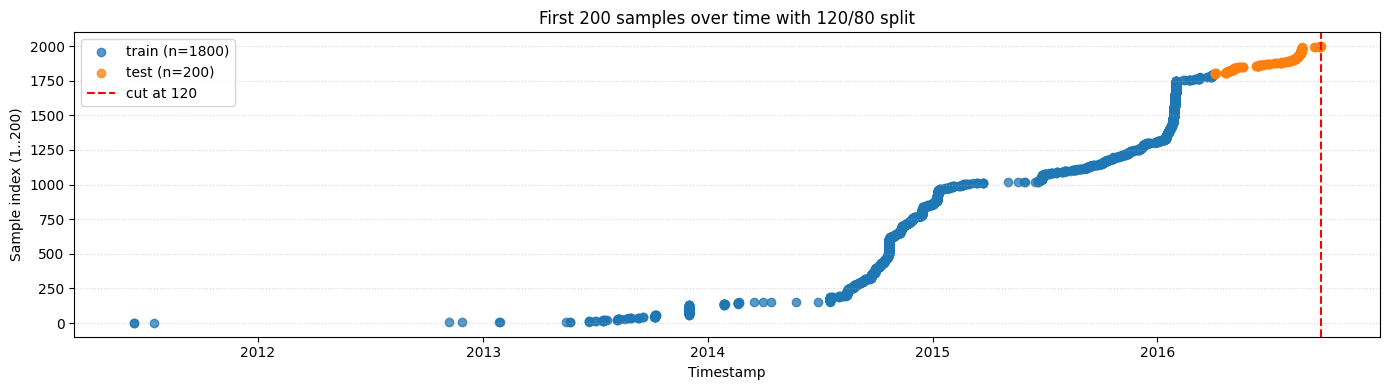

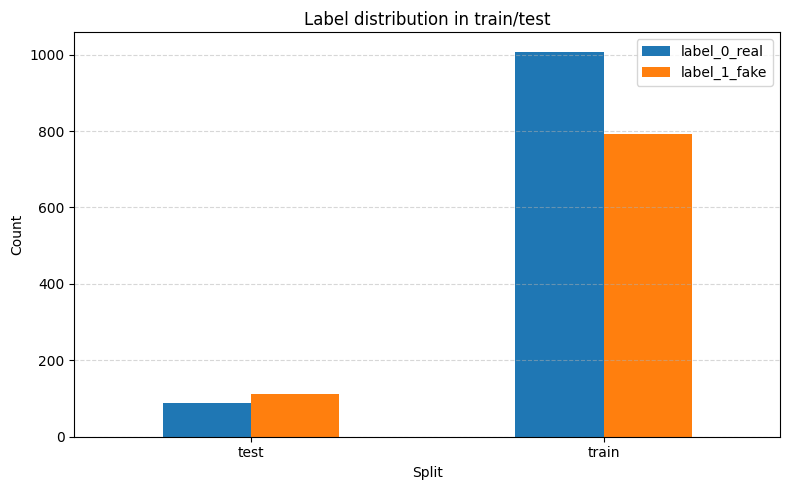

In [9]:
# Time split and distribution
plt.figure(figsize=(14, 4))
for split, color in [('train', 'tab:blue'), ('test', 'tab:orange')]:
    subset = df_200[df_200['split'] == split]
    plt.scatter(subset['timestamp'], subset.index + 1, label=f'{split} (n={len(subset)})', alpha=0.75, color=color)

cut_time = df_200.iloc[1999]['timestamp']
plt.axvline(cut_time, color='red', linestyle='--', label='cut at 120')
plt.title('First 200 samples over time with 120/80 split')
plt.xlabel('Timestamp')
plt.ylabel('Sample index (1..200)')
plt.grid(axis='y', linestyle=':', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

dist = df_200.groupby(['split', 'label_bin']).size().reset_index(name='count')
dist_pivot = dist.pivot(index='split', columns='label_bin', values='count').fillna(0)
dist_pivot.columns = ['label_0_real', 'label_1_fake']
dist_pivot.plot(kind='bar', figsize=(8, 5))
plt.title('Label distribution in train/test')
plt.xlabel('Split')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



# import matplotlib.pyplot as plt

# # --- Biểu đồ 1: Phân bố mẫu theo thời gian thực ---
# plt.figure(figsize=(14, 4))
# for split, color in [('train', 'tab:blue'), ('test', 'tab:orange')]:
#     subset = combined[combined['split'] == split]
#     plt.scatter(subset['timestamp'], subset.index + 1,
#                 label=f'{split} (n={len(subset)})', alpha=0.75, color=color)

# # Đường phân cách giữa train và test (thời điểm cuối của train)
# cut_time = train_df['timestamp'].max()
# plt.axvline(cut_time, color='red', linestyle='--', label='train/test boundary')

# plt.title('Sample distribution over real time (decoded from tweet_id)')
# plt.xlabel('Timestamp')
# plt.ylabel('Sample index (combined order)')
# plt.grid(axis='y', linestyle=':', alpha=0.5)
# plt.legend()
# plt.tight_layout()
# plt.show()

# # --- Biểu đồ 2: Phân bố nhãn trên train/test ---
# dist = combined.groupby(['split', 'label_bin']).size().reset_index(name='count')
# dist_pivot = dist.pivot(index='split', columns='label_bin', values='count').fillna(0)
# dist_pivot.columns = ['label_0_real', 'label_1_fake']

# dist_pivot.plot(kind='bar', figsize=(8, 5))
# plt.title('Label distribution in train/test')
# plt.xlabel('Split')
# plt.ylabel('Count')
# plt.xticks(rotation=0)
# plt.grid(axis='y', linestyle='--', alpha=0.5)
# plt.tight_layout()
# plt.show()

### 3. Fine-tune SLM và đánh giá trên tập test
Huấn luyện SLM trên train, dự đoán test và lưu kết quả SLM-only.

In [10]:
# Fine-tune SLM using FTT weighted training (uniform weights)
train_texts = train_df['text'].tolist()
train_labels = train_df['label_bin'].astype(int).tolist()
test_texts = test_df['text'].tolist()
test_labels = test_df['label_bin'].astype(int).tolist()

SLM_SAVE_DIR = REPO_DIR / 'dataset' / 'slm_120_80'
SLM_SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Uniform weights (all 1.0) for standard fine-tuning
train_weights = [1.0] * len(train_texts)

slm = IntegratedSLM(model_path='bert-base-uncased')  # use pretrained BERT
ft_stats = slm.finetune_weighted(
    train_texts=train_texts,
    train_labels=train_labels,
    train_weights=train_weights,
    epochs=15,                # as before
    batch_size=32,
    lr=4e-5,                  # typical for BERT fine-tuning
    weight_decay=0.01,
    early_stop=5,
    val_texts=test_texts,     # using test as validation for early stopping
    val_labels=test_labels,
    save_path=str(SLM_SAVE_DIR),
)
print('Fine-tune stats:', ft_stats)

# Save FTT checkpoint for MRCD reuse
slm.save(str(SLM_SAVE_DIR))
FTT_CHECKPOINT = str(SLM_SAVE_DIR / "parameter_bert.pkl")
print(f"FTT checkpoint saved at: {FTT_CHECKPOINT}")
# Keep reference for FTT-only evaluation later
slm_ftt = slm

[FTT-SLM] Initialising from: bert-base-uncased


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[FTT-SLM] Model loaded on cuda
[FTT] Epoch 1/15 | loss=0.6682 | val_f1=0.7197
[FTT] Epoch 2/15 | loss=0.5301 | val_f1=0.7281
[FTT] Epoch 3/15 | loss=0.3707 | val_f1=0.5763
[FTT] Epoch 4/15 | loss=0.2210 | val_f1=0.5977
[FTT] Epoch 5/15 | loss=0.1547 | val_f1=0.7143
[FTT] Epoch 6/15 | loss=0.1258 | val_f1=0.7119
[FTT] Epoch 7/15 | loss=0.1220 | val_f1=0.6077
[FTT] Early stop at epoch 7
[FTT] Loaded best checkpoint from /kaggle/working/Fake-news-detection/dataset/slm_120_80/parameter_bert.pkl
Fine-tune stats: {'trained': True, 'samples': 1800, 'epochs_run': 7, 'best_val_f1': 0.7280701754385965, 'train_loss_history': [0.6682364783788982, 0.5301397887238285, 0.3707287149471149, 0.2210333653186497, 0.15471630164405756, 0.12575782793002172, 0.1220080602521959], 'val_f1_history': [0.7196652719665272, 0.7280701754385965, 0.576271186440678, 0.5977011494252874, 0.7142857142857143, 0.711864406779661, 0.6077348066298343]}
[FTT-SLM] Checkpoint saved → /kaggle/working/Fake-news-detection/dataset/slm

In [11]:
import gc
import torch

# 1. Đo lường trước khi dọn
stats_before = []
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        stats_before.append({
            "alloc": torch.cuda.memory_allocated(i) / (1024 ** 2),
            "res": torch.cuda.memory_reserved(i) / (1024 ** 2)
        })

# 2. Giải phóng biến model và dọn rác System RAM
if 'slm' in globals():
    del slm
gc.collect()
torch.cuda.empty_cache()
torch.cuda.synchronize()

# 3. Dọn dẹp VRAM trên TẤT CẢ GPU
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        torch.cuda.set_device(i)
        torch.cuda.empty_cache()
        try:
            torch.cuda.ipc_collect()
        except:
            pass
    
    # Trả về device 0 để tránh lỗi chạy các cell sau
    torch.cuda.set_device(0)

    # 4. In báo cáo so sánh
    print(f"--- VRAM ({torch.cuda.device_count()} GPU) ---")
    for i in range(torch.cuda.device_count()):
        after_alloc = torch.cuda.memory_allocated(i) / (1024 ** 2)
        after_reserved = torch.cuda.memory_reserved(i) / (1024 ** 2)
        print(f"GPU {i}:")
        print(f"  Allocated: {stats_before[i]['alloc']:.1f}MB -> {after_alloc:.1f}MB")
        print(f"  Reserved:  {stats_before[i]['res']:.1f}MB -> {after_reserved:.1f}MB")
else:
    print('Không có CUDA, bỏ qua bước giải phóng VRAM.')

--- VRAM (2 GPU) ---
GPU 0:
  Allocated: 873.3MB -> 873.3MB
  Reserved:  5472.0MB -> 1292.0MB
GPU 1:
  Allocated: 0.0MB -> 0.0MB
  Reserved:  0.0MB -> 0.0MB


### 4. MRCD nhiều vòng (Round-based)


#### 4.1 MRCD - Khởi tạo + Bootstrap + Round 1

In [12]:
from tqdm.auto import tqdm


In [13]:
# import os

# # Thêm đường dẫn chứa libcuda.so vào LD_LIBRARY_PATH
# # Bạn có thể thử lần lượt từng đường dẫn, nhưng ưu tiên dùng /usr/local/nvidia/lib64 trước
# cuda_path = "/usr/local/nvidia/lib64"
# # Hoặc thử với: cuda_path = "/usr/local/cuda-12.5/compat"

# os.environ["LD_LIBRARY_PATH"] = f"{cuda_path}:" + os.environ.get("LD_LIBRARY_PATH", "")
# print("LD_LIBRARY_PATH set to:", os.environ["LD_LIBRARY_PATH"])

In [14]:
# --- Khởi tạo event_states, d_clean, d_noisy, ... ---
# (Phần này nằm trong cell "MRCD - Phần A: Khởi tạo + Bootstrap + Round 1")
events = test_texts
ground_truth = test_labels
llm = get_llm()
static_corpus = load_news_corpus()

mode = 'wiki_only'
wiki_fetch_full = False
event_states = [
    {
        'event_id': i,
        'text': preprocess_text(t),
        'round': 0,
        'status': 'unprocessed',
        'label': None,
        'label_llm': None,
        'label_slm': None,
        'conf_slm': None,
        'llm_raw': None,
        'llm_label_matched': None,
        'retrieval_source': None,
        'knowledge': None,
        'query_context': None,
        'ground_truth': ground_truth[i],
        'prompt': None,
    }
    for i, t in enumerate(events)
]

d_clean = []
d_noisy = []
round_history = []
finetune_history = []
round_eval_rows = []
knowledge_cache_local = {}

print(f'Initialized MRCD with {len(events)} events')

config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

 Loaded LLM: meta-llama/Meta-Llama-3-8B-Instruct
 Loaded 120000 documents from AG News.
Initialized MRCD with 200 events


In [15]:
# Load FTT-pretrained checkpoint into MRCD SLM (NOT training from scratch)
from src.slm.model import IntegratedSLM


# Initialize MRCD SLM and load the FTT-trained weights
slm_mrcd = IntegratedSLM(model_path='bert-base-uncased')
slm_mrcd.load(FTT_CHECKPOINT)
print(f'MRCD SLM loaded FTT checkpoint from: {FTT_CHECKPOINT}')

# Quick verify: FTT-only baseline
slm_ftt_preds = []
for text in test_texts:
    pred, conf, _ = slm_mrcd.inference(text)
    slm_ftt_preds.append(pred)
ftt_only_acc = sum(1 for p, g in zip(slm_ftt_preds, test_labels) if p == g) / len(test_labels)
print(f'FTT-only baseline accuracy: {ftt_only_acc:.4f}')


[FTT-SLM] Initialising from: bert-base-uncased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[FTT-SLM] Model loaded on cuda
[FTT-SLM] Checkpoint loaded ← /kaggle/working/Fake-news-detection/dataset/slm_120_80/parameter_bert.pkl
MRCD SLM loaded FTT checkpoint from: /kaggle/working/Fake-news-detection/dataset/slm_120_80/parameter_bert.pkl
FTT-only baseline accuracy: 0.6900


In [16]:
# Bootstrap context (parallel I/O to speed up retrieval)
from concurrent.futures import ThreadPoolExecutor, as_completed

unique_texts = list(dict.fromkeys([s['text'] for s in event_states]))
context_map = {}


def _fetch_one_context(text):
    return text, prefetch_query_context(
        text=text,
        demo_k=TOP_K_DEMOS,
        fact_top_k=FACT_TOP_K,
        reuse_knowledge_cache=True,
        knowledge_cache_local=knowledge_cache_local,
        knowledge_mode=mode,
        wiki_fetch_full=wiki_fetch_full,
    )
for state in event_states:
    qctx = context_map.get(state['text'], {
        'knowledge_text': 'No info.',
        'bing_seed_news': [],
    })
    state['query_context'] = qctx
    state['knowledge'] = qctx.get('knowledge_text', 'No info.')



In [17]:
CONFIDENCE_THRESHOLD = 0.7

In [18]:
# Round 1
from src.retrieval.demo_retrieval import load_news_corpus
static_corpus = load_news_corpus()
from src.llm.handler import get_llm
round_id = 1
for state in tqdm(event_states, desc='Round 1 - LLM assess'):
    demos, knowledge_k, retrieval_source = build_evidence_bundle(
        text=state['text'],
        static_corpus=static_corpus,
        clean_pool=d_clean,
        round_id=round_id,
        query_context=state['query_context'],
        demo_k=TOP_K_DEMOS,
    )
    assess = assess_with_llm(text=state['text'], demos=demos, knowledge_k=knowledge_k, llm=llm)
    state.update({
        'round': round_id,
        'label': assess['y_llm'],
        'label_llm': assess['y_llm'],
        'llm_raw': assess['llm_raw'],
        'llm_label_matched': assess['llm_label_matched'],
        'retrieval_source': retrieval_source,
        'knowledge': knowledge_k,
        'prompt': assess['prompt'],
    })

slm_batch = slm_mrcd.inference_batch([s['text'] for s in event_states], batch_size=32)
for state, res in tqdm(list(zip(event_states, slm_batch)), desc='Round 1 - merge/split', total=len(event_states)):
    pred, conf, _ = res
    state['label_slm'] = pred
    state['y_slm'] = pred
    state['conf_slm'] = conf

    log_round_trace_to_csv(
        round_id=round_id,
        event_id=state['event_id'],
        text=state['text'],
        y_slm=state['y_slm'],
        y_llm=state['label_llm'],
        ground_truth=state['ground_truth'],
        conf_slm=state['conf_slm'],
        prompt=state['prompt'],
        filepath=str(TRACE_CSV_PATH),
    )

    if split_clean_noisy(state, 0.85):
        state['label'] = pred  # Use SLM label (more accurate than LLM's ~50%)
        state['status'] = 'clean'
        d_clean.append(state)
        log_prediction_to_csv(
            event_id=state['event_id'],
            text=state['text'],
            label=state['label'],
            conf=state['conf_slm'],
            round_id=round_id,
            status=state['status'],
            filepath=str(RESULTS_CSV_PATH),
        )
    else:
        state['status'] = 'noisy'
        d_noisy.append(state)

round_summary = summarize_round_stats(event_states, d_clean, round_id)
round_eval_rows.append(round_summary)
round_history.append({'round': round_id, 'clean_count': len(d_clean), 'noisy_count': len(d_noisy)})
print(f"Round 1 done | clean={len(d_clean)} noisy={len(d_noisy)} | SLM acc={round_summary['slm_round_accuracy']:.4f} | LLM acc={round_summary['llm_round_accuracy']:.4f} | d_clean acc={round_summary['dclean_total_accuracy']:.4f}")

 Loaded 120000 documents from AG News.


Round 1 - LLM assess:   0%|          | 0/200 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Round 1 - merge/split:   0%|          | 0/200 [00:00<?, ?it/s]

Round 1 done | clean=49 noisy=151 | SLM acc=0.6900 | LLM acc=0.6000 | d_clean acc=0.8980


#### 4.1 MRCD - Round 2..N
Fine-tune trên d_clean (nếu đủ mẫu), sau đó tái đánh giá các mẫu noisy.

In [19]:
# MRCD - Phần B: Rounds 2..N
round_id = 2
while d_noisy and round_id <= NUM_LOOP:
    if ENABLE_SLM_FINETUNE and len(d_clean) >= SLM_FINETUNE_MIN_SAMPLES:
        ft = slm_mrcd.finetune_on_clean(
            clean_samples=d_clean,
            epochs=SLM_FINETUNE_EPOCHS,
            batch_size=SLM_FINETUNE_BATCH_SIZE,
            lr=SLM_FINETUNE_LR,
            weight_decay=SLM_FINETUNE_WEIGHT_DECAY,
            val_texts=test_texts,
            val_labels=test_labels,
        )
    else:
        ft = {'trained': False, 'reason': 'disabled_or_insufficient'}
    finetune_history.append({'round': round_id, **ft})

    next_noisy = []
    promoted_clean = 0

    for state in tqdm(d_noisy, desc=f'Round {round_id} - LLM assess'):
        demos, knowledge_k, retrieval_source = build_evidence_bundle(
            text=state['text'],
            static_corpus=static_corpus,
            clean_pool=d_clean,
            round_id=round_id,
            query_context=state['query_context'],
            demo_k=TOP_K_DEMOS,
        )
        assess = assess_with_llm(text=state['text'], demos=demos, knowledge_k=knowledge_k, llm=llm)
        state.update({
            'round': round_id,
            'label': assess['y_llm'],
            'label_llm': assess['y_llm'],
            'llm_raw': assess['llm_raw'],
            'llm_label_matched': assess['llm_label_matched'],
            'retrieval_source': retrieval_source,
            'knowledge': knowledge_k,
            'prompt': assess['prompt'],
        })

    slm_batch = slm_mrcd.inference_batch([s['text'] for s in d_noisy], batch_size=32)
    for state, res in tqdm(list(zip(d_noisy, slm_batch)), desc=f'Round {round_id} - merge/split', total=len(d_noisy)):
        pred, conf, _ = res
        state['label_slm'] = pred
        state['y_slm'] = pred
        state['conf_slm'] = conf

        log_round_trace_to_csv(
            round_id=round_id,
            event_id=state['event_id'],
            text=state['text'],
            y_slm=state['y_slm'],
            y_llm=state['label_llm'],
            ground_truth=state['ground_truth'],
            conf_slm=state['conf_slm'],
            prompt=state['prompt'],
            filepath=str(TRACE_CSV_PATH),
        )

        if split_clean_noisy(state, 0.85):
            state['label'] = pred  # Use SLM label (more accurate than LLM)
            state['status'] = f'clean@round{round_id}'
            d_clean.append(state)
            promoted_clean += 1
            log_prediction_to_csv(
                event_id=state['event_id'],
                text=state['text'],
                label=state['label'],
                conf=state['conf_slm'],
                round_id=round_id,
                status=state['status'],
                filepath=str(RESULTS_CSV_PATH),
            )
        else:
            state['status'] = f'noisy@round{round_id}'
            next_noisy.append(state)

    d_noisy = next_noisy
    round_summary = summarize_round_stats(event_states, d_clean, round_id)
    round_eval_rows.append(round_summary)
    round_history.append({'round': round_id, 'promoted_to_clean': promoted_clean, 'clean_count': len(d_clean), 'noisy_count': len(d_noisy)})

    print(f"Round {round_id} done | +clean={promoted_clean} remain_noisy={len(d_noisy)} | SLM acc={round_summary['slm_round_accuracy']:.4f} | LLM acc={round_summary['llm_round_accuracy']:.4f} | d_clean acc={round_summary['dclean_total_accuracy']:.4f}")
    round_id += 1

[MRCD] Finetune kept: val_f1 0.7281 → 0.7571


Round 2 - LLM assess:   0%|          | 0/151 [00:00<?, ?it/s]

Round 2 - merge/split:   0%|          | 0/151 [00:00<?, ?it/s]

Round 2 done | +clean=63 remain_noisy=88 | SLM acc=0.5828 | LLM acc=0.6358 | d_clean acc=0.7589
[MRCD] Rollback! val_f1 dropped 0.7571 → 0.7279


Round 3 - LLM assess:   0%|          | 0/88 [00:00<?, ?it/s]

Round 3 - merge/split:   0%|          | 0/88 [00:00<?, ?it/s]

Round 3 done | +clean=1 remain_noisy=87 | SLM acc=0.5341 | LLM acc=0.6023 | d_clean acc=0.7611


#### 4.2 MRCD - Chốt kết quả cuối và lưu log
Final judgment cho mẫu noisy còn lại, tính metric cuối và xuất CSV.

In [20]:
# MRCD - Phần C: Final judgment + export
finalized_noisy = []
if d_noisy:
    finalized_noisy = finalize_remaining_noisy_with_slm(d_noisy, slm_mrcd)
    for fs in finalized_noisy:
        fs['status'] = 'finalized_by_slm'
        log_round_trace_to_csv(
            round_id='final_judgment',
            event_id=fs['event_id'],
            text=fs['text'],
            y_slm=fs['label'],
            y_llm=None,
            ground_truth=fs['ground_truth'],
            conf_slm=fs['conf_slm'],
            prompt='N/A (Final SLM Judgment)',
            filepath=str(TRACE_CSV_PATH),
        )
        log_prediction_to_csv(
            event_id=fs['event_id'],
            text=fs['text'],
            label=fs['label'],
            conf=fs['conf_slm'],
            round_id=NUM_LOOP + 1,
            status=fs['status'],
            filepath=str(RESULTS_CSV_PATH),
        )

finalized_map = {x['event_id']: x for x in finalized_noisy}
mrcd_final_pred = []
mrcd_final_conf = []
mrcd_final_status = []
for s in sorted(event_states, key=lambda z: z['event_id']):
    if s['event_id'] in finalized_map:
        fs = finalized_map[s['event_id']]
        mrcd_final_pred.append(int(fs['label']))
        mrcd_final_conf.append(float(fs.get('conf_slm', 0.0)))
        mrcd_final_status.append('finalized_by_slm')
    else:
        mrcd_final_pred.append(int(s['label']))
        mrcd_final_conf.append(float(s.get('conf_slm', 0.0) or 0.0))
        mrcd_final_status.append(str(s.get('status', 'unknown')))

mrcd_acc = accuracy_score(ground_truth, mrcd_final_pred)
mrcd_prec, mrcd_rec, mrcd_f1, _ = precision_recall_fscore_support(ground_truth, mrcd_final_pred, average='binary', zero_division=0)

print(f'MRCD Final Accuracy: {mrcd_acc:.4f}')
print(f'MRCD Precision: {mrcd_prec:.4f} | Recall: {mrcd_rec:.4f} | F1: {mrcd_f1:.4f}')
print(classification_report(ground_truth, mrcd_final_pred, target_names=['real(0)', 'fake(1)'], digits=4))

round_eval_df = pd.DataFrame(round_eval_rows)
round_eval_df.to_csv(MRCD_ROUND_METRICS_CSV, index=False, encoding='utf-8')

pd.DataFrame({
    'event_id': test_df['id'].astype(str).tolist(),
    'timestamp': test_df['timestamp'].astype(str).tolist(),
    'text': test_texts,
    'y_true': ground_truth,
    'y_pred_mrcd': mrcd_final_pred,
    'conf_mrcd': mrcd_final_conf,
    'status_mrcd': mrcd_final_status,
}).to_csv(MRCD_PRED_CSV, index=False, encoding='utf-8')

print(f'Saved trace log: {TRACE_CSV_PATH}')
print(f'Saved result log: {RESULTS_CSV_PATH}')
print(f'Saved round metrics: {MRCD_ROUND_METRICS_CSV}')
print(f'Saved MRCD predictions: {MRCD_PRED_CSV}')

MRCD Final Accuracy: 0.6600
MRCD Precision: 0.6310 | Recall: 0.9464 | F1: 0.7571
              precision    recall  f1-score   support

     real(0)     0.8125    0.2955    0.4333        88
     fake(1)     0.6310    0.9464    0.7571       112

    accuracy                         0.6600       200
   macro avg     0.7217    0.6209    0.5952       200
weighted avg     0.7108    0.6600    0.6147       200

Saved trace log: /kaggle/working/log/mrcd_trace.csv
Saved result log: /kaggle/working/log/mrcd_results.csv
Saved round metrics: /kaggle/working/log/mrcd_round_metrics.csv
Saved MRCD predictions: /kaggle/working/log/mrcd_final_predictions.csv


In [21]:
# Evaluate FTT-only baseline (using original FTT checkpoint, BEFORE MRCD fine-tuning)
slm_ftt_eval = IntegratedSLM(model_path='bert-base-uncased')
slm_ftt_eval.load(FTT_CHECKPOINT)

slm_test_pred = []
slm_test_conf = []
for text in test_texts:
    pred, conf, _ = slm_ftt_eval.inference(text)
    slm_test_pred.append(pred)
    slm_test_conf.append(conf)

slm_acc = accuracy_score(test_labels, slm_test_pred)
slm_prec, slm_rec, slm_f1, _ = precision_recall_fscore_support(test_labels, slm_test_pred, average='binary', zero_division=0)

print(f'FTT-only Accuracy: {slm_acc:.4f}')
print(f'FTT-only Precision: {slm_prec:.4f} | Recall: {slm_rec:.4f} | F1: {slm_f1:.4f}')
print()
print(f'MRCD-FTT Accuracy: {mrcd_acc:.4f}')
print(f'MRCD-FTT F1: {mrcd_f1:.4f}')
print()
delta_acc = mrcd_acc - slm_acc
delta_f1 = mrcd_f1 - slm_f1
print(f'\u0394 Accuracy (MRCD-FTT vs FTT-only): {delta_acc:+.4f}')
print(f'\u0394 F1 (MRCD-FTT vs FTT-only): {delta_f1:+.4f}')

# Clean up
del slm_ftt_eval
import gc; gc.collect()
if torch.cuda.is_available(): torch.cuda.empty_cache()


[FTT-SLM] Initialising from: bert-base-uncased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[FTT-SLM] Model loaded on cuda
[FTT-SLM] Checkpoint loaded ← /kaggle/working/Fake-news-detection/dataset/slm_120_80/parameter_bert.pkl
FTT-only Accuracy: 0.6900
FTT-only Precision: 0.7155 | Recall: 0.7411 | F1: 0.7281

MRCD-FTT Accuracy: 0.6600
MRCD-FTT F1: 0.7571

Δ Accuracy (MRCD-FTT vs FTT-only): -0.0300
Δ F1 (MRCD-FTT vs FTT-only): +0.0291


,round,dclean_added_accuracy,dclean_total_accuracy,slm_round_accuracy,llm_round_accuracy,dclean_added_count,dclean_total_count,slm_round_count,llm_round_count
0,1,0.897959,0.897959,0.690000,0.600000,49,49,200,200
1,2,0.650794,0.758929,0.582781,0.635762,63,112,151,151
2,3,1.000000,0.761062,0.534091,0.602273,1,113,88,88


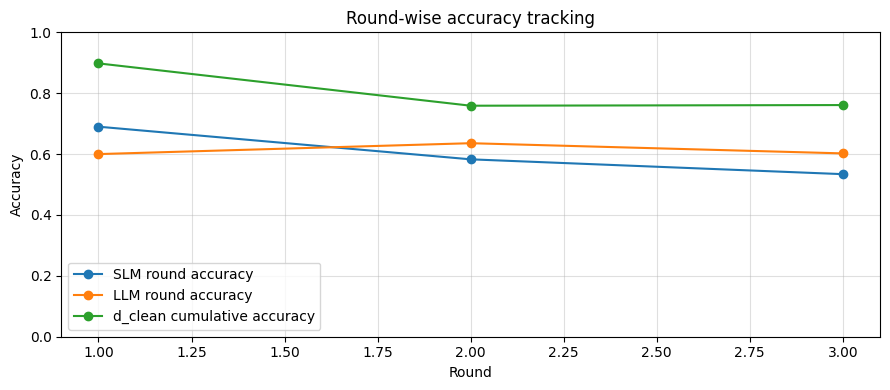

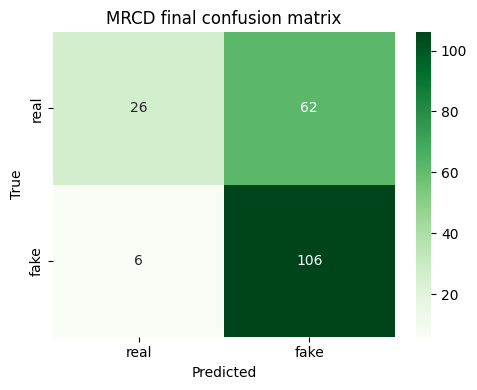

,model,accuracy,precision,recall,f1
0,FTT_only,0.69,0.715517,0.741071,0.728070
1,MRCD,0.66,0.630952,0.946429,0.757143


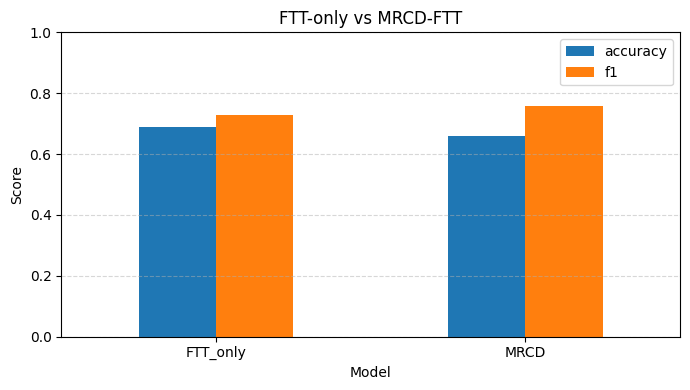

Saved comparison: /kaggle/working/log/slm_vs_mrcd_metrics.csv


In [22]:
# Round-by-round MRCD performance and final comparison
if not round_eval_rows:
    print('No round metrics collected.')
else:
    round_eval_df = pd.DataFrame(round_eval_rows)
    display(round_eval_df[['round', 'dclean_added_accuracy', 'dclean_total_accuracy', 'slm_round_accuracy', 'llm_round_accuracy', 'dclean_added_count', 'dclean_total_count', 'slm_round_count', 'llm_round_count']])

    plt.figure(figsize=(9, 4))
    plt.plot(round_eval_df['round'], round_eval_df['slm_round_accuracy'], marker='o', label='SLM round accuracy')
    plt.plot(round_eval_df['round'], round_eval_df['llm_round_accuracy'], marker='o', label='LLM round accuracy')
    plt.plot(round_eval_df['round'], round_eval_df['dclean_total_accuracy'], marker='o', label='d_clean cumulative accuracy')
    plt.title('Round-wise accuracy tracking')
    plt.xlabel('Round')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.0)
    plt.grid(True, alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

    cm_mrcd = confusion_matrix(ground_truth, mrcd_final_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm_mrcd, annot=True, fmt='d', cmap='Greens', xticklabels=['real', 'fake'], yticklabels=['real', 'fake'])
    plt.title('MRCD final confusion matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

    comparison_df = pd.DataFrame([
        {'model': 'FTT_only', 'accuracy': slm_acc, 'precision': slm_prec, 'recall': slm_rec, 'f1': slm_f1},
        {'model': 'MRCD', 'accuracy': mrcd_acc, 'precision': mrcd_prec, 'recall': mrcd_rec, 'f1': mrcd_f1},
    ])
    comparison_df.to_csv(COMPARISON_CSV, index=False, encoding='utf-8')
    display(comparison_df)

    ax = comparison_df.set_index('model')[['accuracy', 'f1']].plot(kind='bar', figsize=(7, 4))
    ax.set_title('FTT-only vs MRCD-FTT')
    ax.set_xlabel('Model')
    ax.set_ylabel('Score')
    ax.set_ylim(0, 1.0)
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    print(f'Saved comparison: {COMPARISON_CSV}')